# Chicago Risk District Classification
In previous notebooks, we have established that clustering is justified. Our EDA supports a clustering algorithm from multiple perspectives:

1. Temporal analysis - districts exhibit persistent behavior
2. Spatial analysis - significant spatial autocorrelation with Moran's I $=$ 0.431 and its $p$-value of 0.004
3. LISA - well-defined hotspots and coldspots
4. Hopkins statistic - moderate cluster tendency among districts ($H \approx$ 0.64) with very strong structure in the temporal dataset

Now it is time to ask a different question: **how many district profiles exist, and what characterizes each one?** This shifts the focus from *does clustering make sense?* to *what is the best clustering solution?*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from joblib import dump, load

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals

colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT
census_data = pc.CENSUS_DATA

%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

## Modeling: ASLT
In this section we apply the *K-Means* Machine Learning algorithm to perform a cluster analysis on the districts below. Our goal is to assign districts into well-defined clusters, such that we may recognize similar patterns between districts, realocate resources and apply appropriate countermeasures on each. We shall limit our analysis to $k=5$ clusters maximum.

As a first step, we will remove the outliers and variables with Spearman correlation greater than 0.80. As a second step, it is worth mentioning that we will train the clustering algorithm on the entire training dataset, since we have

- thousands of observations
- more stable estimates of centroids
- and each district has been observed under many conditions (weekdays, weekends, holidays, winter...)

but the predict method will be applied only to the latest features, for the object being clustered is the district, not district-days. That is to say, once the centroids are learned in training, we take the latest features and assign each district to the nearest centroid. We can think of it as customer segmentation where the model is trained on every purchase ever made, to learn customer archetypes, then it is classified on today's customer.

In [4]:
train_aslt = pd.read_csv(
    f'{gld_path}/train_aslt.csv',
    index_col='ddate',
    parse_dates=True,
    dtype={
        'district': str
    }
)

# features to train K-Means
features_aslt = train_aslt\
    .drop(columns=['district'])\
    .dropna()\
    .reset_index(drop=True)\
    .copy()

# features to predict
latest_features = train_aslt\
    .groupby('district')\
    .tail(1)\
    .drop(columns=['district'])\
    .reset_index(drop=True)\
    .copy()

# removing outliers
features_aslt = f.rm_outliers(features_aslt, s=3)

features_aslt.head()

N. of outliers: 1801 (5.634%)


,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
0,5.285714,0.293651,0.214286,1.713848,35.387097,37.256894,186.284470,41.198413,0.077781,0.004321,0.003153,0.015556
1,6.857143,0.335793,0.146507,2.484215,21.287635,43.799069,437.990695,33.493734,0.087821,0.004301,0.001876,0.008782
2,5.571429,0.404422,0.236395,2.754716,32.274564,48.763518,390.108148,38.385034,0.055021,0.003994,0.002335,0.006878
3,12.428571,0.397576,0.187977,1.698811,25.040365,44.442936,311.100550,87.822477,0.129360,0.004138,0.001957,0.018480
4,14.857143,0.510369,0.093152,2.142886,28.451400,42.850458,514.205491,65.981803,0.172809,0.005936,0.001083,0.014401


In [ ]:
# Spearman measures monotonic relationship, whereas
# Perason measures strictly linear
features_aslt.corr(method='spearman')

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
ASLT_RollAvg7,1.000000,0.312039,0.097387,0.169154,-0.387906,0.015292,0.237087,0.621488,0.857914,0.176570,0.015797,0.638479
ASLT_RollDRate7,0.312039,1.000000,-0.062633,0.269723,0.206844,-0.006961,0.278831,0.587312,0.198485,0.815437,-0.156738,0.014106
ASLT_RollARate7,0.097387,-0.062633,1.000000,-0.199302,-0.230184,0.264586,-0.120221,0.161457,-0.052841,-0.231937,0.791485,0.125525
ASLT_RollAvgDist7,0.169154,0.269723,-0.199302,1.000000,0.224099,0.006086,0.658221,0.109488,0.171814,0.249553,-0.190945,-0.335156
ASLT_RollAvgMaxDist7,-0.387906,0.206844,-0.230184,0.224099,1.000000,0.058746,0.110737,-0.221079,-0.429942,0.175271,-0.282598,-0.412482
ASLT_RollAvgCMLen7,0.015292,-0.006961,0.264586,0.006086,0.058746,1.000000,0.254128,0.024569,-0.403279,-0.501548,-0.264323,-0.289862
ASLT_RollAvgLen7,0.237087,0.278831,-0.120221,0.658221,0.110737,0.254128,1.000000,0.314122,0.077088,0.101119,-0.323068,-0.521214
ASLT_RollAvgHardship7,0.621488,0.587312,0.161457,0.109488,-0.221079,0.024569,0.314122,1.000000,0.401347,0.377326,-0.028613,0.225698
ASLT_RollAvgCountCMArea7,0.857914,0.198485,-0.052841,0.171814,-0.429942,-0.403279,0.077088,0.401347,1.000000,0.336467,0.170842,0.746772
ASLT_RollAvgDRateCMArea7,0.176570,0.815437,-0.231937,0.249553,0.175271,-0.501548,0.101119,0.377326,0.336467,1.000000,0.008900,0.120913


In [5]:
features_aslt = features_aslt.drop(
    columns=[
        'ASLT_RollAvgCountCMArea7',
        'ASLT_RollAvgDRateCMArea7',
        'ASLT_RollAvgARateCMArea7'
    ]
)

latest_features = latest_features.drop(
    columns=[
        'ASLT_RollAvgCountCMArea7',
        'ASLT_RollAvgDRateCMArea7',
        'ASLT_RollAvgARateCMArea7'
    ] 
)

### Model Specification
We have experimented feature forward selection and exhaustive feature search to develop the best possible model. However, statistics alone may not suffice to build the best possible model regarding risk profile. For instance, when one optimizes metrics such as the silhouette score or Calinski-Harabasz score, one is not pursuing to optimize information content. Consider two models: **A** and **B** where crime count and crime density are variables for the former and crime count, domestic rate, arrest rate, and hardship are variables for the latter. Model **A** may have a better scores because the variables reinforce the same axis (they refer to the same dimension). Model **B**, by its turn, may produce worse geometry, but much richer and more actionable interpretations. Consequently, we believe mthat odel selection should combine quantitative *and* qualitative evaluation.

The exhaustive feature search reveals that the top models are all based on a single variable. At first glance, this seems fantastic, but what K-Means is doing is simply dividing one axis into intervals such as Low, Medium, and High: the cluster are naturally compact because there is only one dimension (silhouette is biased toward low dimensions). As one adds more dimensions, distances become more diffuse. Therefore, comparing one variable with four variables using **only** silhouette is not a fair comparison.

We must remeber the question we want to answer: Can we describe different operational profiles of Chicago police districts? By using only the crime density variable and having Low, Medium, and High density clusters, a police commander would probably not learn anything beyond "this district has more crime per km $^2$. Now comparing that with using variables like density, domestic rate and hardship. One can distinguish

- high-density affluent areas
- high-density disadvantage areas
- domestic-driven districts

which are operational profiles, not merely volume levels.

Rather than searching among subsets of all variables, we propose a handful of interpretable models.

1. Model A - Operational Risk
    - crime density
    - domestic rate
    - arest rate
    - hardship

2. Model B - Operational + Accessibility
    - Model A
    - average distance

3. Model C - Operational + Spatial
    - Model A
    - district length

4. Model D - Crime Dynamics
    - crime count
    - domestic rate
    - arest rate
    - hardship

For each candidate, we evaluate the silhouette score, Calinski-Harabasz, and Davies-Bouldin for $k \in \{2, 3, 4, 5\}$, so as to compare competing theories of district behavior. We have already established that clustering is justified. At this stage, the challenge is no longer finding any cluster structure, but building clusters that are meaningful for decision-making.

#### Operational Risk

In [6]:
model_risk = [
    'ASLT_RollAvgDensity7',
    'ASLT_RollDRate7',
    'ASLT_RollARate7',
    'ASLT_RollAvgHardship7'
]

output = {}
k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_risk = scaler_aslt.fit_transform(features_aslt[model_risk])
X_latest_risk = scaler_aslt.transform(latest_features[model_risk])

output['risk'] = f.KMeans_features(X_risk, X_latest_risk, k_values)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


#### Risk + Accessibility

In [7]:
model_access = model_risk + ['ASLT_RollAvgDist7']

k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_access = scaler_aslt.fit_transform(features_aslt[model_access])
X_latest_access = scaler_aslt.transform(latest_features[model_access])

output['accessibility'] = f.KMeans_features(X_access, X_latest_access, k_values)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


In [24]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_access)

profiles_access = train_aslt.groupby('district').tail(1).copy()
profiles_access['cluster'] = kmeans.predict(X_latest_access)
profiles_access[model_access + ['cluster']].groupby('cluster').median()

,ASLT_RollAvgDensity7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7,ASLT_RollAvgDist7
cluster,,,,,
0,0.010034,0.384938,0.296376,62.839286,2.735978
1,0.010603,0.217001,0.168139,14.872279,1.658094
2,0.024640,0.388188,0.296630,73.000000,1.843187


#### Risk + Spatial

In [30]:
model_spatial = model_risk + ['ASLT_RollAvgLen7']

k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_spatial = scaler_aslt.fit_transform(features_aslt[model_spatial])
X_latest_spatial = scaler_aslt.transform(latest_features[model_spatial])

output['spatial'] = f.KMeans_features(X_spatial, X_latest_spatial, k_values)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


#### Dynamics

In [31]:
model_dyn = [
    'ASLT_RollAvg7',
    'ASLT_RollDRate7',
    'ASLT_RollARate7',
    'ASLT_RollAvgHardship7'
]

k_values = range(2, 6)

scaler_aslt = StandardScaler()

X_dyn = scaler_aslt.fit_transform(features_aslt[model_dyn])
X_latest_dyn = scaler_aslt.transform(latest_features[model_dyn])

output['dynamics'] = f.KMeans_features(X_dyn, X_latest_dyn, k_values)

Initiating k=2
Initiating k=3
Initiating k=4
Initiating k=5


With all metrics calculated, we build a model dataframe so we have an easier manipulation. We then plot them individually.

In [32]:
models = pd.DataFrame()
for key in output.keys():
    df_ = pd.DataFrame(output[key])
    df_['model'] = key
    df_['k'] = [2, 3, 4, 5]
    models = pd.concat([models, df_], axis=0, ignore_index=True)

models

,sse,silhouettes,ch,db,model,k
0,81344.743959,0.293950,9.601034,1.224172,risk,2
1,64073.850806,0.246420,9.277977,1.222093,risk,3
2,51940.240782,0.176764,8.864983,1.162547,risk,4
3,44150.503940,0.209512,9.051653,1.100528,risk,5
4,110550.887870,0.222009,6.239162,1.346837,accessibility,2
5,82253.010443,0.241840,7.876401,1.243795,accessibility,3
6,73905.305618,0.231062,6.820786,1.080423,accessibility,4
7,64674.676880,0.192373,7.796062,1.062564,accessibility,5
8,110937.234089,0.265431,7.671829,1.487080,spatial,2
9,77720.431841,0.268670,9.291408,1.116794,spatial,3


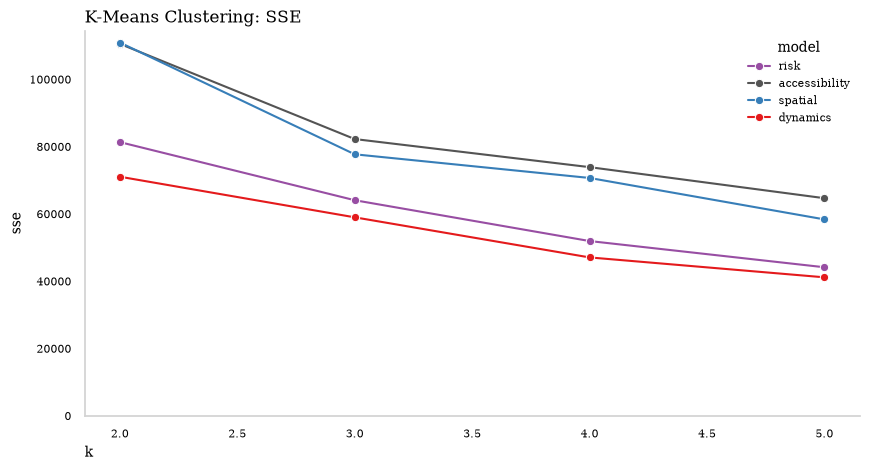

In [33]:
sns.lineplot(
    data=models,
    x='k',
    y='sse',
    hue='model',
    marker='o',
    palette={
        '#e41a1c',
        '#377eb8',
        '#545454',
        '#984ea3'
    }
)
plt.ylim(0)
plt.xlabel('k', loc='left')
plt.title('K-Means Clustering: SSE', loc='left');

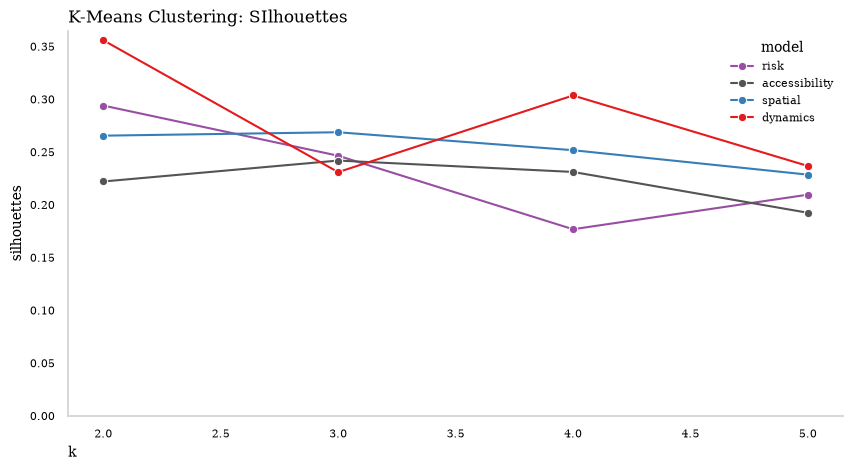

In [34]:
sns.lineplot(
    data=models,
    x='k',
    y='silhouettes',
    hue='model',
    marker='o',
    palette={
        '#e41a1c',
        '#377eb8',
        '#545454',
        '#984ea3'
    }
)
plt.ylim(0)
plt.xlabel('k', loc='left')
plt.title('K-Means Clustering: SIlhouettes', loc='left');

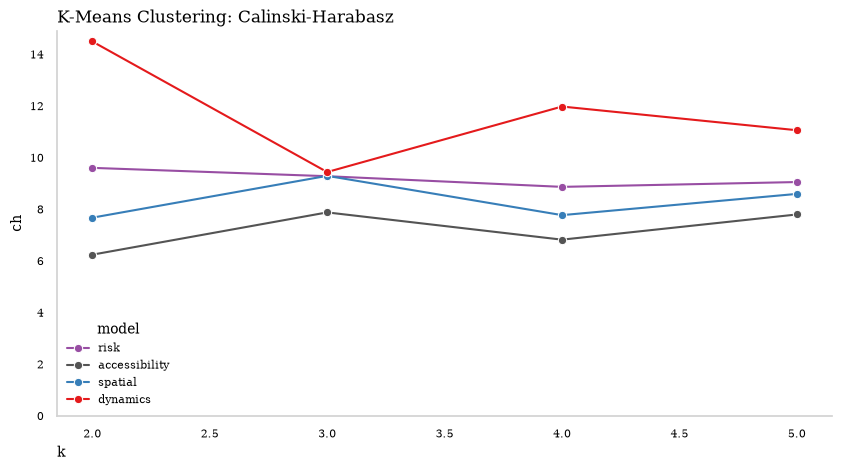

In [35]:
sns.lineplot(
    data=models,
    x='k',
    y='ch',
    hue='model',
    marker='o',
    palette={
        '#e41a1c',
        '#377eb8',
        '#545454',
        '#984ea3'
    }
)
plt.ylim(0)
plt.xlabel('k', loc='left')
plt.title('K-Means Clustering: Calinski-Harabasz', loc='left');

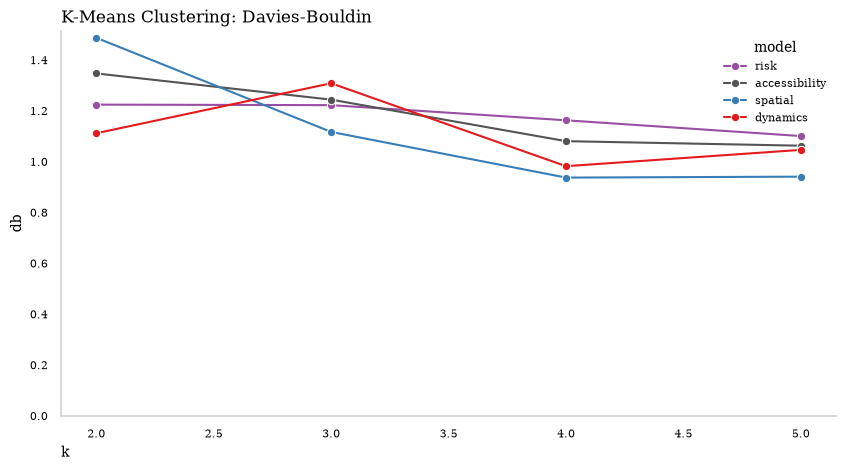

In [36]:
sns.lineplot(
    data=models,
    x='k',
    y='db',
    hue='model',
    marker='o',
    palette={
        '#e41a1c',
        '#377eb8',
        '#545454',
        '#984ea3'
    }
)
plt.ylim(0)
plt.xlabel('k', loc='left')
plt.title('K-Means Clustering: Davies-Bouldin', loc='left');

For interpretability, we can also visualize the clusters defined by each model. We choose $k^\ast = 3$ since its clusters can be easility interpreted.

In [25]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_risk)

profiles_risk = train_aslt.groupby('district').tail(1).copy()
profiles_risk['cluster'] = kmeans.predict(X_latest_risk)
profiles_risk[model_risk + ['cluster']].groupby('cluster').median()

,ASLT_RollAvgDensity7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7
cluster,,,,
0,0.010163,0.384938,0.216837,62.839286
1,0.010603,0.194728,0.209981,14.872279
2,0.028459,0.398440,0.331181,73.000000


In [26]:
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_access)

profiles_access = train_aslt.groupby('district').tail(1).copy()
profiles_access['cluster'] = kmeans.predict(X_latest_access)
profiles_access[model_access + ['cluster']].groupby('cluster').median()

,ASLT_RollAvgDensity7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7,ASLT_RollAvgDist7
cluster,,,,,
0,0.010034,0.384938,0.296376,62.839286,2.735978
1,0.010603,0.217001,0.168139,14.872279,1.658094
2,0.024640,0.388188,0.296630,73.000000,1.843187


In [37]:
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_spatial)

profiles_spatial = train_aslt.groupby('district').tail(1).copy()
profiles_spatial['cluster'] = kmeans.predict(X_latest_spatial)
profiles_spatial[model_spatial + ['cluster']].groupby('cluster').median()

,ASLT_RollAvgDensity7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7,ASLT_RollAvgLen7
cluster,,,,,
0,0.024640,0.388188,0.296630,73.000000,306.578082
1,0.010034,0.384938,0.296376,62.839286,506.067496
2,0.010603,0.217001,0.168139,14.872279,314.523200


In [38]:
kmeans = KMeans(n_clusters=k_opt, random_state=1, n_init=50)
kmeans.fit(X_dyn)

profiles_dyn = train_aslt.groupby('district').tail(1).copy()
profiles_dyn['cluster'] = kmeans.predict(X_latest_dyn)
profiles_dyn[model_dyn + ['cluster']].groupby('cluster').median()

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7
cluster,,,,
0,12.785714,0.379467,0.189808,62.092185
1,6.571429,0.217001,0.168139,21.188690
2,9.142857,0.393707,0.328090,69.373699


We now have several plausible models, each representing a different philosophy of risk. The question becomes: *Which definition of risk best serves our project's objetive?*

We can compare them from three perspectives: i) statistical quality; ii) interpretability; and iii) operational usefulness.

i) From a purely numerical standpoint, dynamics wins most of the time and accessibility is the weakest overall.

ii) By interpreting the clusters:
- Risk tells a coherent story, since the clusters are easily interpreted
    - cluster 0 represents low-risk districts
    - cluster 1 represents socioeconomically vulnerable districts
    - cluster 2 represents high-risk districts
- Adding distance creates a distiction, for 0 and 2 have similar characteristics, but different average distances
    - does that distinction matter for district classification? From a crime-profile perspective, probably not
- Adding district length separates districts primarily according to their geometry
    - cluster 2 differs mostly because the districts are physically larger
    - does that define a crime profile? Probably not
- Dynamics also tells a coherent story, as the cluster are immediately understandable
    - cluster 1: stable, low-risk districts
    - cluster 0: persistent domestic and violent districts
    - cluster 2: critical districts

iii) Therefore, we resume our discussion between Risk and Dynamics, where the only substantial difference is the first variable: crime density vs crime count. The density model is excellent for measuring spatial intensity, but we understand that police commanders usually allocate officers based on expected workload, not crimes per square km. We also understand that crime volume must be the true KPI for our project, so we adopt the Dynamics model as our final model.

### Cluster Interpretation: Dynamics Model
Our variables are:

1. ASLT_RollAvg7 - assault workload
2. ASLT_RollDRate7 - share of domestic assaults
3. ASLT_RollARate7 - arrest effectiveness
4. ASLT_RollAvgHardship - socioeconomic vulnerability

Notice these four variables answer four complementary questions:

- how much crime occurs?
- what type of assaults predominate?
- how effectively are incidents resolved?
- what social environment surrounds those crimes?

As such, we can interpret the clusters as follows.

**Cluster 1: Stable Districts**

Represents the safest districts in the city.

Characteristics:
- lowest assault workload
- low domestic violence
- relatively low arrest rate
- low socioeconomic vulnerability

The lower arrest rate should not necessarily be interpreted as poorer policing. Rather, it is likely a consequence of fewer incidents requiring police intervention, such that routine policing is generally sufficient.

*Priority: Monitor.*

**Cluster 0: Vulnerable Residential Districts**

Compared to Cluster 1:
- assault volume nearly doubles
- domestic violence increase substantially
- hardship nearly triples

Domestic violence is one of the defining characteristics of this cluster. This suggests districts where assaults are strongly associated with persistent social vulnerability rather than extreme crime concentration.

Operationally, these districts may benefit less from reactive patrol strategies and more from coordinated interventions involving social services, family protection programs and community policing.

*Priority: Prevent.*

**Cluster 2: Critical Districts**

Represents the highest-risk districts. It simultaneously exhibits

- the greatest assault workload
- the highest domestic violence share
- the highest socioeconomic vulnerability
- the highest arrest rate

Rather than indicating that crime is under control, the higher arrest rate likely reflects increased police activity in response to elevated crime levels. These districts experience both high crime demand and intensive policing.

*Priority: Intervene.*

One thing particularly interesting is that the clusters form a natural progression: every variable moves in the expected direction, implying that not only is crime increasing, but, rather, that crime intensity, domestic violence, and socioeconomic vulnerability rises together. In other words, districts with higher assault acitivty also tend to exhibit greater socioeconomic hardship and a larger proportion of domestic violence incidents. The increase in arrest rate across clusters suggests that policing effort also intensifies as districts become more challenging. This framing shifts the conversation from simply labeling districts as Low, Medium and High crime to explaining why they differ and what type of response may be the most approriate.

We next save our model and scaler for future use.

In [27]:
dump(scaler_aslt, f'{model_path}/scaler_aslt.pkl')
dump(kmeans, f'{model_path}/kmeans_aslt.pkl')

['../../models/kmeans_aslt.pkl']

### Strategic Use for Clusters: ASLT
The profiles can be used mainly to **i)** prioritze resource distribution across districts; **ii)** design tailored community safety programs; **iii)** understand Chicago main risk profile; and **iv)** guide further predictive modelling or risk scoring (model's result can serve as input for another models).

In particular for item **iii)**, if we calculate the district distribution per cluster (next section), we find ~23% in Cluster 3, which is a zone with high crime activity both in the streets and inside the residences. That corrobarates with the high crime volume in all Chicago, where we obtain an average of ~14 occurrences in a 7-day window, which is 2 occurrences per day, yielding almost 1,000 in a year. Therein, we have also ~20% of average arrest rate, roughly saying that most of offenders, 4 out of 5, remain in the open. As for item **i)**, we understand that Cluster 3 deserves special attention, as they represent poorer areas with the highest intensity, where we must ensure continued support for enforcement and investments on social interventions must be prioritized in order to reduce long-term pressure.

In [30]:
print(train_aslt['ASLT_RollAvg7'].mean())
print(train_aslt['ASLT_RollARate7'].mean())

14.433316839651605
0.18688522601676325


### Cluster Distribution
One interest measure to have is the cluster distribution, to assess how crime volume is located in Chicago. To this end, we get the latest date available for each district, which is 2024-12-31, and calculate the percentage cluster distribution for this date.

In [5]:
kmeans_aslt = load(f'{model_path}/kmeans_aslt.pkl')
scaler_aslt = load(f'{model_path}/scaler_aslt.pkl')

In [6]:
cluster_aslt = train_aslt.dropna().reset_index(drop=True).copy()

X_aslt = scaler_aslt.transform(cluster_aslt[features_list])

cluster_aslt['cluster'] = [pc.cluster_mapping['ASLT'][x] for x in kmeans_aslt.predict(X_aslt)]

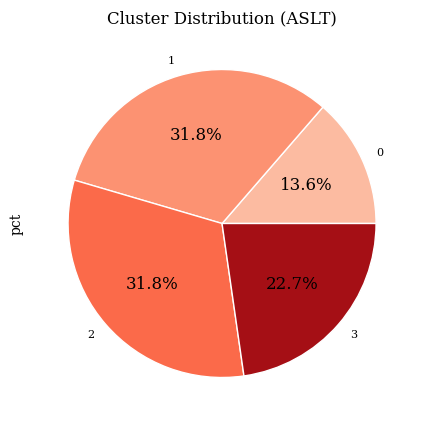

In [10]:
# getting the latest date for each district
date_df = cluster_aslt[['date', 'district']]\
    .groupby('district')\
    .max()\
    .reset_index()

# merging to get only the latest date records and hence the latest clusters
aux = cluster_aslt[['date', 'district', 'cluster']]\
    .merge(
        date_df,
        on=['date', 'district'],
        how='inner'
    )

# calculating the percentage distribution of clusters
aux = aux[['district', 'cluster']]\
    .groupby('cluster')\
    .count() / len(aux)

aux = aux.rename(columns={'district': 'pct'})

aux.plot(
    kind='pie',
    y='pct',
    autopct='%1.1f%%',
    legend=False,
    colors= pc.CLUSTER_COLORS['hex'].values(),
    title='Cluster Distribution (ASLT)'
);

plt.savefig(f'{img_path}/fig28.png', dpi=300)

The distribution above, however, varies over time, since our metrics are dynamic (based on a rolling window). The plot below thus shows its evolvution in time.

In [31]:
daily_dist = (
    cluster_aslt[['district', 'date', 'cluster']]
    .groupby(['date', 'cluster'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .reset_index(level=0, drop=True)
    .to_frame(name='pct')
    .reset_index()
)
daily_dist

,date,cluster,pct
0,2022-01-07,0,0.090909
1,2022-01-07,1,0.363636
2,2022-01-07,2,0.090909
3,2022-01-07,3,0.454545
4,2022-01-08,0,0.045455
...,...,...,...
4354,2024-12-30,3,0.238095
4355,2024-12-31,0,0.136364
4356,2024-12-31,1,0.272727
4357,2024-12-31,2,0.363636


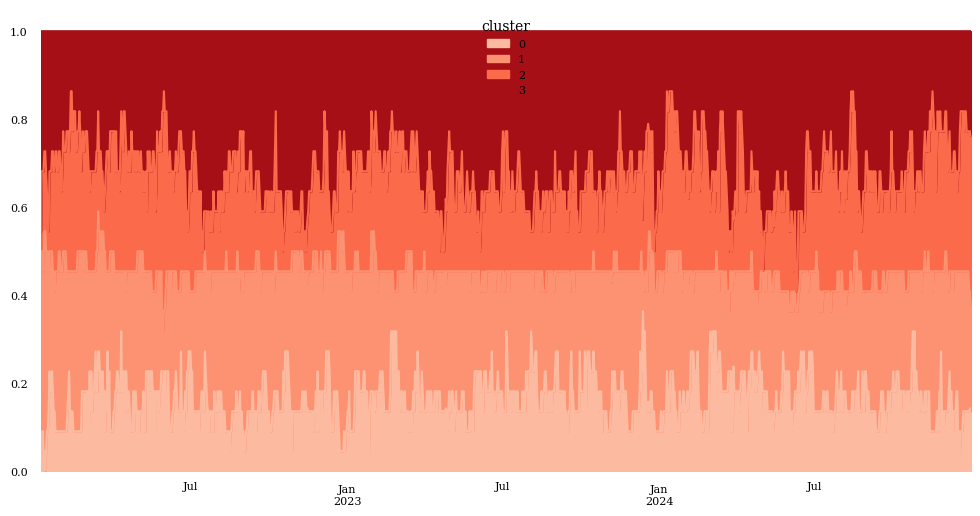

In [50]:
daily_dist.pivot(
    index='date',
    columns='cluster',
    values='pct'
).plot.area(
    color=pc.CLUSTER_COLORS['hex'],
    figsize=(12, 6)
)
plt.xlabel('')
plt.box(False)

We see a prevalence of cluster 3, with nearly 40% of the distribution at some points, indicating that most districts of Chicago is in a high-risk state/cluster. This aligns with real-world [data](https://counciloncj.org/crime-in-chicago-what-you-need-to-know/) showing persistent violent neighborhoods in Chicago.

Later, we will evaluate the transition matrix, where each element represents transition probabilities between clusters, and will find that each cluster is stable enough such that there is a 90% historical probability of a district to remain at cluster 3 once it has reached it, hence reflecting structural inequality.

By choosing a particular district, for illustration, we are able to see how its cluster changes along the way by plotting cluster vs date. We observe that it alternates between clusters 0, 2 and 3, suggesting that we can also consider a measure of cluster volatility to quantify such variations.

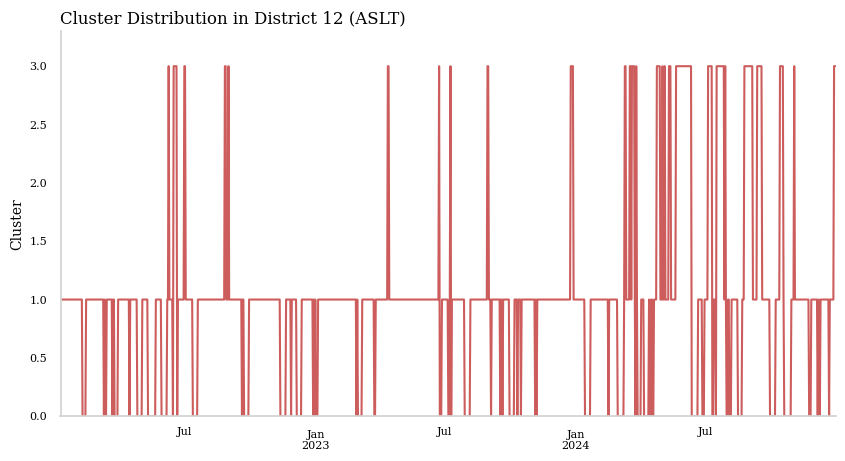

In [31]:
d = '12'
aux = cluster_aslt[['district', 'date', 'cluster']]\
    .query('district == @d')

aux['cluster'] = aux['cluster'].astype(int)

aux.plot(
    x='date',
    y='cluster',
    color='indianred',
    legend=False
)
plt.title(f'Cluster Distribution in District {d} (ASLT)', loc='left')
plt.ylim(0, (k_opt - 1) * 1.1)
plt.ylabel('Cluster')
plt.xlabel('');

plt.savefig(f'{img_path}/fig29.png', dpi=300)

### Cluster Intensity and Volatility
To aid in comparisons among districts, we can define *cluster intensity* and *cluster volatility* as numeric measures to quantify how aggressive a cluster is and how volatile a district is through time, that is, how often it shifts from cluster $m$ to $n$, with $m \neq n$, and how strong is the shift. Moreover, we have seen that $0 \to 1 \to 2 \to 3$ increases in overall crime volume and aggressiveness, such that Cluster 3 is represented by more aggressive districts than Cluster 1. In other words, aggressiveness increases as $n$ increases.

As for the volatility, it is interesting to consider a measure that encompasses the shift strength and frequency. For instance, a district that shifts from $0 \to 1$ must be less volatile than one that shifts from $0 \to 2$ or $0 \to 3$, considering the same time period. We thus seek a measure of the form $$V_{mn} = \frac{1}{\Delta t} \left|{I_n - I_m} \right|,$$ where $I_n$ stands for the $n$-th cluster intensity, which is some monotonic function of $n$, such that it must satisfy $$I_n > I_m, \qquad n > m.$$ The denominator $\Delta t$ represents the time period, in days, under consideration. For convenience, we consider $\Delta t = 7$, to match the 7-day window above.

The cluster intensity can be defined simply as $$I_n \coloneqq \ln (1 + n), \qquad n \in \{0, 1, 2, 3\},$$ since it satisfies all necessary conditions, is a well-behaved function, and $I_0=0$. Thefore, we end up with $$V_{mn} = \frac{1}{7} \left| \frac{\ln(1 + n)}{\ln( 1 + m)} \right|.$$ Obs: one could also consider some linear function $I_n = n$, yielding $V_{mn} = (1/7) |n - m|$, but such function could be problematic in case of eventual integrations.

Below we see its graphic representation through time for some districts.

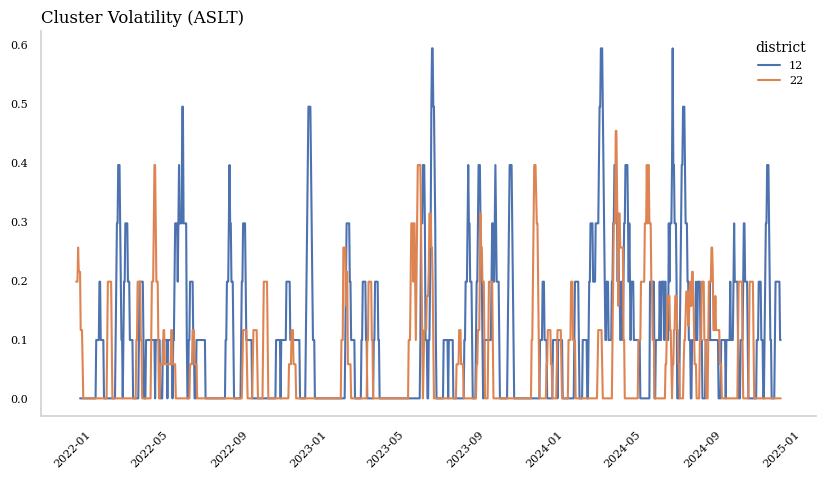

In [33]:
districts = ['12', '22']

aux = cluster_aslt[cluster_aslt['district'].isin(districts)]\
    [['date', 'district', 'cluster']]\
    .copy()


aux['cluster_intensity'] = aux['cluster'].apply(f.cluster_intensity, scale='log')
aux['cluster_vol'] = aux['cluster_intensity']\
    .diff().abs()\
    .fillna(0)\
    .rolling(7).mean()

sns.lineplot(
    data=aux,
    x='date',
    y='cluster_vol',
    hue='district'
)
plt.title('Cluster Volatility (ASLT)', loc='left')
plt.ylabel('')
plt.xticks(rotation=45)
plt.xlabel('');

plt.savefig(f'{img_path}/fig30.png', dpi=300)

## Transition Matrix
A cluster transition matrix is one of the most powerful tools one can use when in possession of a cluster over time dataframe. It gives a single, interpretable view of how districts migrate from one risk profile to another over time. Formally, it is a $k \times k$ matrix, with $k$ the number of clusters, and with elements $T_{mn}$ representing the probability that a district moves from cluster $m$ to cluster $n$.

In [10]:
transition_matrix = f.get_transition_matrix(cluster_aslt)
transition_matrix

next_cluster,0,1,2,3
cluster,,,,
0,0.886323,0.111647,0.001269,0.000761
1,0.063882,0.916327,0.008586,0.011205
2,0.000953,0.010863,0.886030,0.102154
3,0.000634,0.009643,0.068519,0.921203


From the matrix above, we obtain a meanigufl model of violence evolution. Particularly, we note that:
- all clusters are extremely stable on a weekly basis (diagonal values), indicating that
    - the clustering captured true structural patterns and not just random noise
    - interventions needs months, not days, to show effect, which aligns well from what is known from criminology: **i)** social condition, policing, and community factors change slowly; and **ii)** districts rarely jump from safe to high-violence in a short window, showing that the model behaves realistically
- districts in low-risk areas most commonly drift toward cluster 1 and not toward high-violence clusters (row 0), suggesting cluster 1 as a transitional zone
- districts where domestic violence is dominant tend to stay that way, but have some improvement if local enforcenment improves (row 1)
- cluster 2 is an escalation threshold (it is the tipping point) with almost no recovery to low-risk groups (row 2), meaning that cluster 2 requires early intervention before it becomes cluster 3
- once a districts reaches high violence, it almost never goes back down (row 3), thus being a long-term risk condition

## OOT
In this section we evaluate the model in an out-of-time period, much like the testing set. We can perform the same analysis, but comparing them with training period to assess data and model drift.

In [11]:
oot_aslt = pd.read_csv(f'{gld_path}/oot_aslt.csv')
oot_aslt['date'] = pd.to_datetime(oot_aslt['date'])
oot_aslt['district'] = oot_aslt['district'].astype(str)

oot_aslt.head()

,district,date,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgDist7,ASLT_RollAvgMaxDist7,ASLT_RollAvgCMLen7,ASLT_RollAvgLen7,ASLT_RollAvgHardship7,ASLT_RollAvgCountCMArea7,ASLT_RollAvgDRateCMArea7,ASLT_RollAvgARateCMArea7,ASLT_RollAvgDensity7
0,1,2025-01-01,14.285714,0.239165,0.264814,1.905682,20.446880,42.99766,300.983622,8.465852,0.205510,0.003441,0.003810,0.029359
1,1,2025-01-02,14.000000,0.296308,0.231481,1.868721,20.389907,42.99766,300.983622,8.056328,0.201399,0.004263,0.003330,0.028771
2,1,2025-01-03,13.857143,0.270117,0.261243,1.755878,20.259152,42.99766,300.983622,8.265852,0.199344,0.003886,0.003758,0.028478
3,1,2025-01-04,13.714286,0.236567,0.239598,1.769777,20.333694,42.99766,300.983622,7.179272,0.197289,0.003403,0.003447,0.028184
4,1,2025-01-05,14.714286,0.216399,0.255564,1.864371,20.420306,42.99766,300.983622,6.870028,0.211675,0.003113,0.003676,0.030239


In [12]:
features_oot = oot_aslt[features_list].copy()
kmeans_aslt = load(f'{model_path}/kmeans_aslt.pkl')
scaler_aslt = load(f'{model_path}/scaler_aslt.pkl')

From the training period, we notice a difference in the ASLT_RollAvg7 distribution.

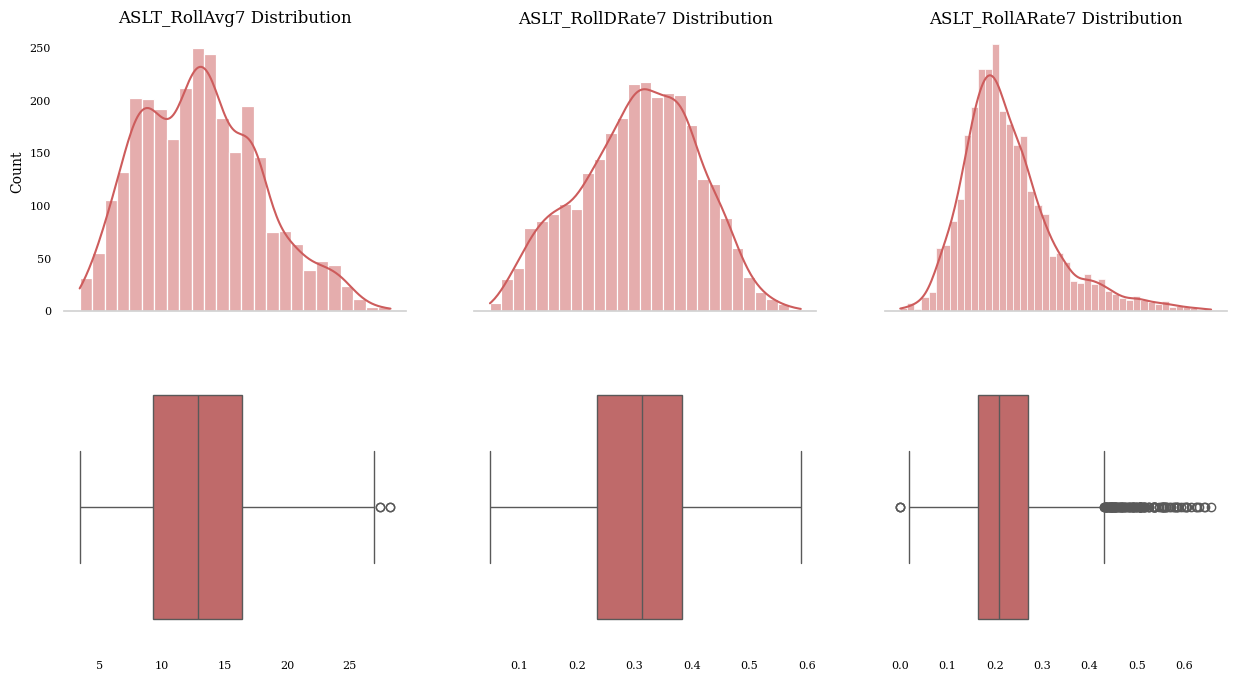

In [23]:
f.gen_paired_hist_box(
    features_oot[[
        f'{grp}_RollAvg7',
        f'{grp}_RollDRate7',
        f'{grp}_RollARate7',
    ]]
)

Regarding the cluster medians, we see no significant changes.

In [13]:
cluster_oot = oot_aslt.dropna().reset_index(drop=True).copy()

X_oot = scaler_aslt.transform(features_oot)

cluster_oot['cluster'] = [pc.cluster_mapping['ASLT'][x] for x in kmeans_aslt.predict(X_oot)]

cluster_oot[features_list + ['cluster']]\
    .groupby('cluster')\
    .agg(['median'])

,ASLT_RollAvg7,ASLT_RollDRate7,ASLT_RollARate7,ASLT_RollAvgHardship7
,median,median,median,median
cluster,,,,
0,10.285714,0.168504,0.246344,10.134419
1,8.285714,0.281689,0.157143,31.162302
2,14.857143,0.337636,0.272260,73.000000
3,17.000000,0.390854,0.170928,60.994851


The transition matrix, by its turn, shows a slight shift for some values. In particular, of greater significance, there is no jump between clusters 0 and 3, since $T_{03} = T_{30} = 0$, $T_{32}$ has doubled, and the stability of the clusters is preserved.

In [14]:
f.get_transition_matrix(cluster_oot)

next_cluster,0,1,2,3
cluster,,,,
0,0.888016,0.110020,0.001965,0.000000
1,0.070496,0.908616,0.014360,0.006527
2,0.001961,0.008824,0.917647,0.071569
3,0.000000,0.017078,0.132827,0.850095


### Kullback-Leibler Divergence
The Kullback-Leibler Divergence (KLD) is a statistical measure used to quanify how one probability distribution differs from another. It tells us how much information is gained when the actual distribution of events deviates from a reference distribution.

In our context, the distribution will be evaluated on a weekly period, such that, each week the city has a certain proportion of districts assigned to each cluster. We then compare this weekly distribution to a baseline distribution, which refers to the historical pattern learned from the trained period (2022-2024). If the weekly distribution is similar to the baseline, the KLD is close to zero. If the distribution begins to shift, with more districts entering high-risk cluster, for example, the KLD increases, signaling the system is moving away from its historical state. It then provides a single continuous metric for detecting early signs of risk escalation, hence informing model retraining, that can be monitored over time.

Mathematically, it is given by the expression $$\text{KLD}(p||q) = \sum_x p_x \log\frac{p_x}{q_x},$$ where $p_x$ is a probability distribution over variable $x$ and $q_x$ is the baseline distribution, over the same variable.

In [ ]:
# we thus start by calculating the  baseline distribution
baseline_dist = cluster_aslt.groupby('cluster').size().div(len(cluster_aslt))
baseline_dist

cluster
0    0.164587
1    0.287026
2    0.219296
3    0.329091
dtype: float64

In [ ]:
# afterwards, we calculate the weekly distribution in the OOT period
cluster_oot['week'] = cluster_oot['date'].dt.to_period('W').dt.start_time

weekly_dist = (
    cluster_oot
    .groupby(['week', 'cluster'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .reset_index(level=0, drop=True)
    .to_frame(name='pct')
    .reset_index()
)
weekly_dist

,week,cluster,pct
0,2024-12-30,0,0.145455
1,2024-12-30,1,0.272727
2,2024-12-30,2,0.327273
3,2024-12-30,3,0.254545
4,2025-01-06,0,0.162338
...,...,...,...
71,2025-04-28,3,0.240260
72,2025-05-05,0,0.094828
73,2025-05-05,1,0.379310
74,2025-05-05,2,0.258621


In [17]:
q = baseline_dist.values

kld_records = []
for w in weekly_dist['week'].unique():
    dist_w = weekly_dist.query('week == @w').set_index('cluster')['pct']
    p = dist_w.reindex(baseline_dist.index, fill_value=0).values

    kld_records.append({'week': w, 'kld': f.kld(p, q)})

df_kld = pd.DataFrame(kld_records)
df_kld

,week,kld
0,2024-12-30,0.033738
1,2025-01-06,0.122771
2,2025-01-13,0.093966
3,2025-01-20,0.191407
4,2025-01-27,0.180617
5,2025-02-03,0.140227
6,2025-02-10,0.169004
7,2025-02-17,0.149978
8,2025-02-24,0.163862
9,2025-03-03,0.096340


We observe values greater than 0.10 at the start of 2025 from the 3 week moving average of the KLD below. As highlighted in the 02 Notebook, the start of every year is a notorious time period, with a greater frequency of occurrences. As they refer to outliers regarding a date point of view, it is expected to see a higher KLD.

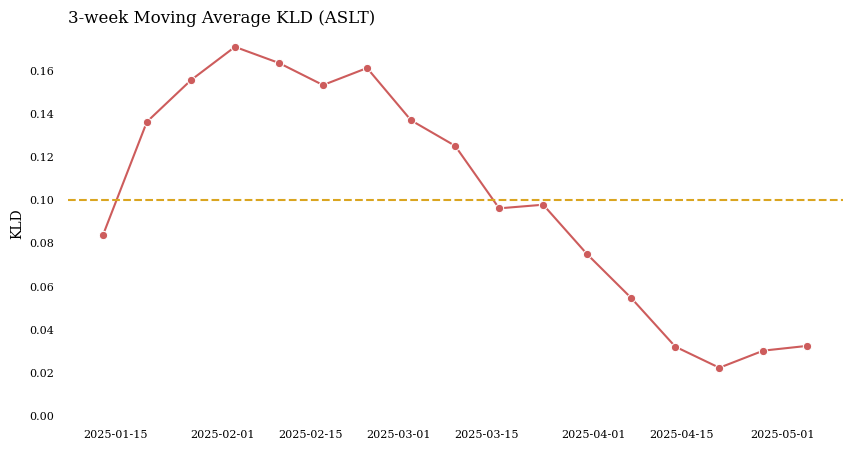

In [28]:
sns.lineplot(
    data=df_kld.set_index('week').rolling(3).mean(),
    x='week',
    y='kld',
    marker='o',
    color=colors['ASLT']
)
plt.title('3-week Moving Average KLD (ASLT)', loc='left')
plt.axhline(y=0.1, color='goldenrod', linestyle='--')
plt.ylim(0)
plt.ylabel('KLD')
plt.xlabel('')
plt.box(False)